# Data preprocessing and cleaning

This notebook builds one row per delivered order for the promise-band task, and a separate order–seller bridge for the history features in `03_feature_engineering.ipynb`.

The boundary matches the group repository's `02_preprocessing.ipynb`: load the raw tables, confirm the order grain, aggregate fields known at purchase, define the cohort and the target, then export. Seller, customer, category, route, and marketplace history are not computed here. There is no global imputation, encoding, scaling, or outlier clipping. Those steps, if a model needs them, are fit on the training rows inside the later pipeline.

Two choices differ from that notebook, on purpose:

1. **Target.** Three bands of the quoted window, using timestamps. `under_half` if actual / promised < 0.5, `half_to_full` if the ratio is from 0.5 up to 1, `late` if the ratio is above 1. Promised time is `order_estimated_delivery_date - order_purchase_timestamp`. The estimate in this extract is midnight, so a delivery later on the promised calendar day is late. The repository's classification target is binary `is_late` on calendar dates, which does not mark that same-day delivery as late.
2. **Split.** Purchases are cut at the 70th and 85th percentiles into train / val / test. An order may enter train only if it was purchased before the validation cut **and** delivered before that cut. The same rule, at the test cut, defines validation, because feature selection reads validation labels. Purchases that were still in transit at the cut are kept with `split = excluded` so their eventual delivery can still feed a later order's history. Test keeps every purchase in the test window. The repository cuts on 30 June and 31 July 2018 and does not drop in-flight labels.

**Decision time.** Purchase. Reviews are not loaded. Approval time, carrier handoff, and the seller shipping deadline are not exported as features.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 140)

ROOT = Path.cwd()
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "IT5006_Project-Data").exists() or (candidate / "data" / "raw").is_dir():
        ROOT = candidate
        break

RAW_CANDIDATES = [
    ROOT / "data" / "raw",
    ROOT / "IT5006_Project-Data" / "Olist_CSV",
    Path("/content/drive/MyDrive/it5006_project/data/raw_data"),
]
RAW = next(path for path in RAW_CANDIDATES if path.exists())
OUT = ROOT / "data" / "processed"
FIG = ROOT / "figures"
OUT.mkdir(parents=True, exist_ok=True)
FIG.mkdir(parents=True, exist_ok=True)

BANDS = ["under_half", "half_to_full", "late"]
BAND_COLORS = {"under_half": "#4C78A8", "half_to_full": "#F2C14E", "late": "#E45756"}
print("data directory:", RAW)


data directory: /Users/Ailurophile/Documents/IT5006/Project/IT5006_Project-Data/Olist_CSV


## 1. Load the raw tables

Review data are not loaded. A review is written after delivery. Geolocation is reduced to one median coordinate per zip-code prefix before any join, so duplicate zip rows cannot multiply orders.


In [3]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]
orders = pd.read_csv(RAW / "olist_orders_dataset.csv", parse_dates=date_columns)
items = pd.read_csv(RAW / "olist_order_items_dataset.csv", parse_dates=["shipping_limit_date"])
products = pd.read_csv(RAW / "olist_products_dataset.csv")
customers = pd.read_csv(RAW / "olist_customers_dataset.csv")
sellers = pd.read_csv(RAW / "olist_sellers_dataset.csv")
payments = pd.read_csv(RAW / "olist_order_payments_dataset.csv")
translation = pd.read_csv(RAW / "product_category_name_translation.csv")
geolocation = pd.read_csv(
    RAW / "olist_geolocation_dataset.csv",
    usecols=["geolocation_zip_code_prefix", "geolocation_lat", "geolocation_lng"],
)

inventory = pd.DataFrame({
    "rows": [len(frame) for frame in [orders, items, products, customers, sellers, payments, geolocation]],
    "unique_orders": [
        orders["order_id"].nunique(),
        items["order_id"].nunique(),
        np.nan,
        np.nan,
        np.nan,
        payments["order_id"].nunique(),
        np.nan,
    ],
}, index=["orders", "items", "products", "customers", "sellers", "payments", "geolocation"])
print(inventory.to_string())


                rows  unique_orders
orders         99441        99441.0
items         112650        98666.0
products       32951            NaN
customers      99441            NaN
sellers         3095            NaN
payments      103886        99440.0
geolocation  1000163            NaN


## 2. Confirm the modelling grain

Actual and estimated delivery timestamps exist only on the order. An order can contain several items and more than one seller, but there is no item-level delivery timestamp. The modelling grain is one row per `order_id`.


In [5]:
item_grain = items.groupby("order_id").agg(
    item_rows=("order_item_id", "size"),
    products=("product_id", "nunique"),
    sellers=("seller_id", "nunique"),
    shipping_deadlines=("shipping_limit_date", "nunique"),
)
grain_check = pd.Series({
    "orders_with_items": len(item_grain),
    "multi_item_orders": int(item_grain["item_rows"].gt(1).sum()),
    "multi_product_orders": int(item_grain["products"].gt(1).sum()),
    "multi_seller_orders": int(item_grain["sellers"].gt(1).sum()),
    "orders_with_multiple_shipping_deadlines": int(item_grain["shipping_deadlines"].gt(1).sum()),
})
print(grain_check.to_frame("orders").to_string())
assert not orders["order_id"].duplicated().any()
assert not items.duplicated(["order_id", "order_item_id"]).any()


                                         orders
orders_with_items                         98666
multi_item_orders                          9803
multi_product_orders                       3236
multi_seller_orders                        1278
orders_with_multiple_shipping_deadlines     336


## 3. Aggregate purchase-time information to order level

Item price, freight, and catalog size are summed to the order. The primary seller is the seller of the highest-priced item, breaking ties on `order_item_id`. That seller's state and zip code are the ones joined below. Every seller on the order is kept in the bridge, because a later history feature has to see multi-seller orders.

Geolocation points outside a Brazil bounding box (latitude −34 to 6, longitude −75 to −32) are dropped before the zip-code median. The repository uses a slightly tighter longitude box, −74 to −34. Distances are great-circle kilometres between those zip centroids, not road distance.

Payment shares are the fraction of payment rows of each type. Missing categories are filled with `unknown` rather than dropped.


In [7]:
products = products.merge(translation, on="product_category_name", how="left")
products["category"] = (
    products["product_category_name_english"]
    .fillna(products["product_category_name"])
    .fillna("unknown")
)
products["volume_cm3"] = (
    products["product_length_cm"] * products["product_height_cm"] * products["product_width_cm"]
)
item_f = items.merge(
    products[[
        "product_id",
        "category",
        "product_weight_g",
        "volume_cm3",
        "product_photos_qty",
        "product_name_lenght",
        "product_description_lenght",
    ]],
    on="product_id",
    how="left",
)
item_f["category"] = item_f["category"].fillna("unknown")


def _sum_min1(series):
    return series.sum(min_count=1)


basket = item_f.groupby("order_id").agg(
    n_items=("order_item_id", "size"),
    n_sellers=("seller_id", "nunique"),
    n_products=("product_id", "nunique"),
    n_categories=("category", "nunique"),
    price_sum=("price", "sum"),
    price_mean=("price", "mean"),
    price_max=("price", "max"),
    freight_sum=("freight_value", "sum"),
    freight_mean=("freight_value", "mean"),
    weight_g_sum=("product_weight_g", _sum_min1),
    weight_g_max=("product_weight_g", "max"),
    volume_cm3_sum=("volume_cm3", _sum_min1),
    volume_cm3_max=("volume_cm3", "max"),
    photos_max=("product_photos_qty", "max"),
    name_len_mean=("product_name_lenght", "mean"),
    desc_len_mean=("product_description_lenght", "mean"),
)
primary = (
    item_f.sort_values(["order_id", "price", "order_item_id"], ascending=[True, False, True])
    .drop_duplicates("order_id")
    [["order_id", "seller_id", "product_id", "category"]]
    .rename(columns={"product_id": "primary_product_id", "category": "product_category"})
)
seller_pairs = item_f[["order_id", "seller_id"]].drop_duplicates()

geo = geolocation.loc[
    geolocation["geolocation_lat"].between(-34, 6) & geolocation["geolocation_lng"].between(-75, -32)
].copy()
centroids = (
    geo.groupby("geolocation_zip_code_prefix")[["geolocation_lat", "geolocation_lng"]]
    .median()
    .reset_index()
    .rename(columns={"geolocation_zip_code_prefix": "zip_prefix"})
)
assert not centroids["zip_prefix"].duplicated().any()


def attach_centroid(frame, zip_col, prefix):
    zips = pd.to_numeric(frame[zip_col], errors="coerce")
    lookup = centroids.rename(columns={
        "geolocation_lat": f"{prefix}_lat",
        "geolocation_lng": f"{prefix}_lng",
    }).copy()
    lookup["zip_prefix"] = lookup["zip_prefix"].astype(float)
    attached = pd.DataFrame({"zip_prefix": zips.to_numpy(dtype=float)}).merge(
        lookup, on="zip_prefix", how="left"
    )
    frame[f"{prefix}_lat"] = attached[f"{prefix}_lat"].to_numpy()
    frame[f"{prefix}_lng"] = attached[f"{prefix}_lng"].to_numpy()
    return frame


def haversine_km(lat1, lon1, lat2, lon2):
    radius = 6371.0
    rad = np.pi / 180
    dlat = (lat2 - lat1) * rad
    dlon = (lon2 - lon1) * rad
    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1 * rad) * np.cos(lat2 * rad) * np.sin(dlon / 2) ** 2
    )
    return 2 * radius * np.arcsin(np.sqrt(np.clip(a, 0, 1)))


pay_agg = payments.groupby("order_id").agg(
    n_payments=("payment_sequential", "size"),
    installments_max=("payment_installments", "max"),
    payment_value_sum=("payment_value", "sum"),
)
pay_share = pd.crosstab(payments["order_id"], payments["payment_type"], normalize="index")
pay_share = pay_share.add_prefix("pay_")
for col in ["pay_credit_card", "pay_boleto", "pay_voucher", "pay_debit_card"]:
    if col not in pay_share.columns:
        pay_share[col] = 0.0
pay_share = pay_share[["pay_credit_card", "pay_boleto", "pay_voucher", "pay_debit_card"]]
print(f"order-level baskets: {len(basket):,}")
print(f"zip centroids: {len(centroids):,}")


order-level baskets: 98,666
zip centroids: 19,011


## 4. Define the eligible delivery cohort and the target

Only `delivered` orders can be labelled. Cancelled, shipped, and unavailable orders are a different problem and are not negative examples of `late`.

Rows are dropped when the delivery or the estimate is missing, when the parcel is timestamped before the purchase, or when the promised window is not positive.

`is_late` and `is_under_half` are stored on the base table so the next notebook can build history. They are label components, not model features. `actual_days` and `duration_ratio` are diagnostics for the same reason.


In [9]:
funnel = [("all orders", len(orders))]
cohort = orders.loc[orders["order_status"].eq("delivered")].copy()
funnel.append(("delivered", len(cohort)))
cohort = cohort.dropna(
    subset=["order_purchase_timestamp", "order_delivered_customer_date", "order_estimated_delivery_date"]
)
funnel.append(("delivery and estimate present", len(cohort)))

cohort["actual_hours"] = (
    cohort["order_delivered_customer_date"] - cohort["order_purchase_timestamp"]
).dt.total_seconds() / 3600
cohort["promised_hours"] = (
    cohort["order_estimated_delivery_date"] - cohort["order_purchase_timestamp"]
).dt.total_seconds() / 3600
valid = (cohort["actual_hours"] >= 0) & (cohort["promised_hours"] > 0)
cohort = cohort.loc[valid].copy()
funnel.append(("positive promised window and delivery after purchase", len(cohort)))

cohort["actual_days"] = cohort["actual_hours"] / 24
cohort["promised_days"] = cohort["promised_hours"] / 24
cohort["duration_ratio"] = cohort["actual_hours"] / cohort["promised_hours"]
cohort["promise_band"] = np.select(
    [cohort["duration_ratio"] < 0.5, cohort["duration_ratio"] <= 1],
    ["under_half", "half_to_full"],
    default="late",
)
cohort["promise_band"] = pd.Categorical(cohort["promise_band"], categories=BANDS, ordered=True)
cohort["is_under_half"] = cohort["promise_band"].eq("under_half").astype(np.int8)
cohort["is_late"] = cohort["promise_band"].eq("late").astype(np.int8)

funnel_df = pd.DataFrame(funnel, columns=["stage", "orders"])
funnel_df["dropped"] = funnel_df["orders"].shift(1) - funnel_df["orders"]
print(funnel_df.to_string(index=False))
print()
mix = cohort["promise_band"].value_counts(normalize=True).reindex(BANDS)
print("class share (%):")
print((mix * 100).round(1).to_string())


                                               stage  orders  dropped
                                          all orders   99441      NaN
                                           delivered   96478   2963.0
                       delivery and estimate present   96470      8.0
positive promised window and delivery after purchase   96470      0.0

class share (%):
promise_band
under_half      57.7
half_to_full    34.2
late             8.1


## 5. Class mix over time

The proposal table summarises this target as about 60/32/8, and a later slide writes 51/41/9. The cell above is the mix on this extract. The 51/41/9 figure is not the chronological test split. Months with a higher late share, notably November 2017 and February–March 2018, sit in the early part of the purchase timeline, which is why the split below stays chronological.


Highest late-share months:
purchase_month
2018-03-01    21.4
2018-02-01    16.0
2017-11-01    14.3
2018-08-01    10.4
2017-12-01     8.4


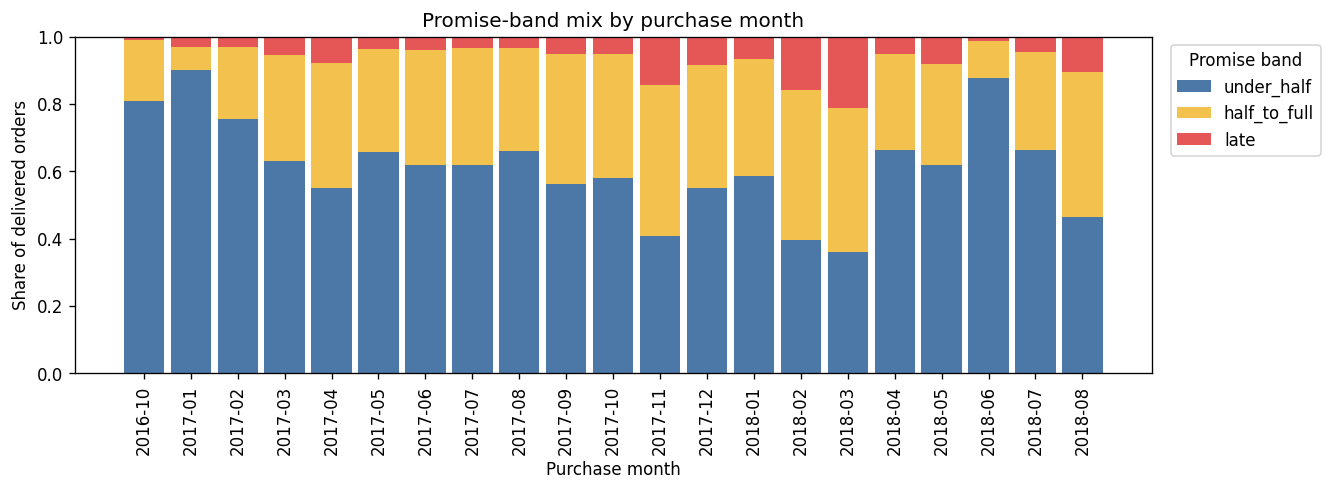

In [11]:
plot_df = cohort.copy()
plot_df["purchase_month"] = plot_df["order_purchase_timestamp"].dt.to_period("M").dt.to_timestamp()
month_n = plot_df.groupby("purchase_month").size()
mix_m = (
    plot_df.groupby("purchase_month", observed=True)["promise_band"]
    .value_counts(normalize=True)
    .unstack()
    .reindex(columns=BANDS)
)
keep = month_n[month_n >= 200].index
mix_m = mix_m.loc[mix_m.index.isin(keep)]

fig, ax = plt.subplots(figsize=(11.2, 4.2))
bottom = np.zeros(len(mix_m))
x = np.arange(len(mix_m))
for band in BANDS:
    values = mix_m[band].to_numpy()
    ax.bar(x, values, bottom=bottom, width=0.86, color=BAND_COLORS[band], label=band)
    bottom = bottom + values
ax.set_ylim(0, 1)
ax.set_ylabel("Share of delivered orders")
ax.set_xlabel("Purchase month")
ax.set_xticks(x)
ax.set_xticklabels([t.strftime("%Y-%m") for t in mix_m.index], rotation=90)
ax.legend(title="Promise band", loc="upper left", bbox_to_anchor=(1.01, 1))
ax.set_title("Promise-band mix by purchase month")
fig.tight_layout()
fig.savefig(FIG / "promise_band_monthly_mix.png", dpi=140)
plt.show()

late_rank = mix_m["late"].sort_values(ascending=False).head(5)
print("Highest late-share months:")
print((late_rank * 100).round(1).to_string())


## 6. Join and clean the order-level table

No global imputation, one-hot encoding, scaling, or outlier clipping is applied. Missing zip centroids stay missing. A missing payment row stays missing. The tree in the next notebook can split on that missingness.


In [13]:
df = cohort.merge(
    customers[["customer_id", "customer_unique_id", "customer_zip_code_prefix", "customer_state"]],
    on="customer_id",
    how="left",
)
before_items = len(df)
df = df.merge(basket, on="order_id", how="inner").merge(primary, on="order_id", how="left")
print(f"orders without items dropped: {before_items - len(df)}")
df = df.merge(
    sellers[["seller_id", "seller_zip_code_prefix", "seller_state"]],
    on="seller_id",
    how="left",
)
df["product_category"] = df["product_category"].fillna("unknown")
df["seller_id"] = df["seller_id"].fillna("unknown")
df["customer_state"] = df["customer_state"].fillna("unknown")
df["seller_state"] = df["seller_state"].fillna("unknown")
df["freight_to_price"] = np.where(df["price_sum"] > 0, df["freight_sum"] / df["price_sum"], np.nan)
df["same_state"] = (df["customer_state"] == df["seller_state"]).astype(np.int8)
df["route"] = df["seller_state"] + ">" + df["customer_state"]
df = attach_centroid(df, "customer_zip_code_prefix", "customer")
df = attach_centroid(df, "seller_zip_code_prefix", "seller")
df["distance_km"] = haversine_km(
    df["customer_lat"].to_numpy(),
    df["customer_lng"].to_numpy(),
    df["seller_lat"].to_numpy(),
    df["seller_lng"].to_numpy(),
)
df["distance_missing"] = df["distance_km"].isna().astype(np.int8)
df = df.merge(pay_agg, on="order_id", how="left").merge(pay_share, on="order_id", how="left")
df["purchase_hour"] = df["order_purchase_timestamp"].dt.hour.astype(np.int16)
df["purchase_dow"] = df["order_purchase_timestamp"].dt.dayofweek.astype(np.int16)
df["purchase_month"] = df["order_purchase_timestamp"].dt.month.astype(np.int16)
df["is_weekend"] = df["purchase_dow"].ge(5).astype(np.int8)
print(f"multi-seller orders: {100 * df['n_sellers'].gt(1).mean():.1f}%")
print(f"distance missing: {100 * df['distance_missing'].mean():.1f}%")
print("payment rows missing:", int(df["n_payments"].isna().sum()))
print(df["distance_km"].describe(percentiles=[0.5, 0.9]).round(1).to_string())


orders without items dropped: 0
multi-seller orders: 1.3%
distance missing: 0.5%
payment rows missing: 1
count    95993.0
mean       600.4
std        592.4
min          0.0
50%        433.8
90%       1456.6
max       3398.5


## 7. Outlier diagnostics

Extreme delivery times, prices, and freight values are retained. Clipping them before the split would use validation and test rows. A robust transform, if one is needed, belongs in the training pipeline.


In [15]:
diagnostic_columns = [
    "actual_days",
    "promised_days",
    "price_sum",
    "freight_sum",
    "distance_km",
    "n_items",
    "weight_g_sum",
]
print(df[diagnostic_columns].describe(percentiles=[0.01, 0.5, 0.95, 0.99, 0.999]).T.round(2).to_string())


                 count     mean      std   min      1%     50%       95%       99%     99.9%        max
actual_days    96470.0    12.56     9.55  0.53    1.83   10.22     29.27     46.05     83.14     209.63
promised_days  96470.0    23.74     8.76  2.01    6.05   23.23     38.42     50.21     66.64     155.14
price_sum      96470.0   137.04   209.05  0.85   11.99   86.50    399.00    990.00   2258.00   13440.00
freight_sum    96470.0    22.79    21.56  0.00    7.39   17.17     54.78    104.25    232.88    1794.96
distance_km    95993.0   600.40   592.36  0.00    5.73  433.80   2095.17   2482.47   3118.57    3398.49
n_items        96470.0     1.14     0.54  1.00    1.00    1.00      2.00      3.00      6.00      21.00
weight_g_sum   96454.0  2386.87  4770.11  0.00  100.00  750.00  10500.00  22350.00  47932.05  184400.00


## 8. Chronological split, then in-flight labels

Cuts fall on purchase timestamps of the joined cohort, so orders placed at the same second stay together. Validation chooses the feature set. Test is scored once, after that choice is frozen.

The purchase cut alone is not enough. An order bought in March and delivered in April was not yet labelled on the April cut. Train keeps a row only when `order_purchase_timestamp < t_val` and `order_delivered_customer_date < t_val`. Validation keeps a row only when the purchase is in the validation window and the delivery is before `t_test`. Everything else purchased before `t_test` is `excluded`. Those rows stay in the table. The next notebook may use them as history once they have been delivered, and must not train on them.


In [17]:
df = df.sort_values(["order_purchase_timestamp", "order_id"]).reset_index(drop=True)
n = len(df)
t_val = df.loc[int(n * 0.70), "order_purchase_timestamp"]
t_test = df.loc[int(n * 0.85), "order_purchase_timestamp"]
purchase = df["order_purchase_timestamp"]
delivered = df["order_delivered_customer_date"]
train_ok = purchase.lt(t_val) & delivered.lt(t_val)
val_ok = purchase.ge(t_val) & purchase.lt(t_test) & delivered.lt(t_test)
df["split"] = np.select(
    [train_ok, val_ok, purchase.lt(t_test)],
    ["train", "val", "excluded"],
    default="test",
)

rows = []
for name in ["train", "excluded", "val", "test"]:
    part = df.loc[df["split"].eq(name)]
    shares = part["promise_band"].value_counts(normalize=True).reindex(BANDS)
    rows.append({
        "split": name,
        "orders": len(part),
        "from": part["order_purchase_timestamp"].min(),
        "to": part["order_purchase_timestamp"].max(),
        **{f"{band}_pct": round(100 * share, 1) for band, share in shares.items()},
    })
split_summary = pd.DataFrame(rows)
print(split_summary.to_string(index=False))
print()
print("validation starts at", t_val)
print("test starts at", t_test)
assert df.loc[df["split"].eq("train"), "order_delivered_customer_date"].max() < t_val
assert df.loc[df["split"].eq("val"), "order_delivered_customer_date"].max() < t_test
assert set(df["split"].unique()) == {"train", "val", "test", "excluded"}
split_summary.to_csv(OUT / "promise_band_split_summary.csv", index=False)


   split  orders                from                  to  under_half_pct  half_to_full_pct  late_pct
   train   64429 2016-09-15 12:16:38 2018-04-13 13:01:55            55.3              36.8       8.0
excluded    5029 2017-11-25 12:14:38 2018-06-21 08:29:29            48.6              30.1      21.3
     val   12541 2018-04-15 20:17:11 2018-06-19 13:09:39            70.5              24.1       5.4
    test   14471 2018-06-21 08:41:07 2018-08-29 15:00:37            60.7              32.7       6.6

validation starts at 2018-04-15 20:17:11
test starts at 2018-06-21 08:41:07


## 9. Right-censoring of the latest purchases

The extract ends at the last recorded delivery. An order enters this cohort only once it is delivered, so a purchase near the end of the file is observed only if it arrived before that last delivery. Orders still pending exist in earlier months as well, so pending status alone is not a censoring correction. The missing delivery times are unknown. This is a limitation to report, not a row to impute.


In [19]:
data_end = orders["order_delivered_customer_date"].max()
pending_status = ["shipped", "invoiced", "processing", "approved", "created"]
recent = orders.loc[orders["order_purchase_timestamp"].ge("2018-03-01")].copy()
recent["purchase_month"] = recent["order_purchase_timestamp"].dt.to_period("M").astype(str)
censoring = recent.groupby("purchase_month").agg(
    orders=("order_id", "size"),
    still_pending=("order_status", lambda s: int(s.isin(pending_status).sum())),
    last_purchase=("order_purchase_timestamp", "max"),
)
censoring["pending_share"] = censoring["still_pending"] / censoring["orders"]
censoring["max_observable_days"] = (data_end - censoring["last_purchase"]).dt.days
print("Last recorded delivery:", data_end)
print(censoring.round(4).to_string())


Last recorded delivery: 2018-10-17 13:22:46
                orders  still_pending       last_purchase  pending_share  max_observable_days
purchase_month                                                                               
2018-03           7211            165 2018-03-31 23:54:10         0.0229                  199
2018-04           6939            121 2018-04-30 23:47:26         0.0174                  169
2018-05           6873             84 2018-05-31 23:51:24         0.0122                  138
2018-06           6167             46 2018-06-30 23:59:49         0.0075                  108
2018-07           6292             74 2018-07-31 23:54:20         0.0118                   77
2018-08           6512             70 2018-08-31 16:13:44         0.0107                   46
2018-09             16              1 2018-09-29 09:13:03         0.0625                   18
2018-10              4              0 2018-10-17 17:30:18         0.0000                   -1


cell_19:13: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.


## 10. Validation and export

`promise_band_base.csv` is the order-level table. `order_seller_bridge.csv` is one row per order–seller pair on that cohort, for history that has to see every seller on a multi-seller order.

`order_delivered_customer_date` is exported as a meta column. The next notebook needs it to decide which past deliveries were already known, and to keep the in-flight rule auditable. It is not a feature. Approval time, carrier handoff, order status, the shipping deadline, and reviews are not exported.


In [21]:
BASE_FEATURES = [
    "n_items", "n_sellers", "n_products", "n_categories",
    "price_sum", "price_mean", "price_max",
    "freight_sum", "freight_mean", "freight_to_price",
    "weight_g_sum", "weight_g_max", "volume_cm3_sum", "volume_cm3_max",
    "photos_max", "name_len_mean", "desc_len_mean", "product_category",
    "customer_state", "seller_state", "same_state",
    "distance_km", "distance_missing", "customer_lat", "customer_lng", "seller_lat", "seller_lng",
    "purchase_hour", "purchase_dow", "purchase_month", "is_weekend",
    "n_payments", "installments_max", "payment_value_sum",
    "pay_credit_card", "pay_boleto", "pay_voucher", "pay_debit_card",
    "promised_days",
]
LABEL_HELPERS = ["is_late", "is_under_half", "actual_days", "duration_ratio"]
META = [
    "order_id", "customer_unique_id", "seller_id",
    "order_purchase_timestamp", "order_delivered_customer_date",
    "split", "promise_band", "route",
]
prohibited = {
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_status",
    "shipping_limit_date",
    "review_score",
    "review_comment_message",
    "actual_hours",
}
assert not prohibited.intersection(BASE_FEATURES)
assert df["order_id"].is_unique
assert df["promise_band"].isin(BANDS).all()
assert df["actual_days"].ge(0).all()
assert df["promised_days"].gt(0).all()

base = df[META + LABEL_HELPERS + BASE_FEATURES].copy()
base_path = OUT / "promise_band_base.csv"
base.to_csv(base_path, index=False)

bridge = seller_pairs.merge(df[["order_id"]], on="order_id", how="inner")
assert not bridge.duplicated(["order_id", "seller_id"]).any()
assert bridge["order_id"].nunique() == len(base)
bridge_path = OUT / "order_seller_bridge.csv"
bridge.to_csv(bridge_path, index=False)

print(f"base table: {base.shape} -> {base_path}")
print(f"seller bridge: {bridge.shape} -> {bridge_path}")
print(base["split"].value_counts().to_string())


base table: (96470, 51) -> /Users/Ailurophile/Documents/IT5006/Project/data/processed/promise_band_base.csv
seller bridge: (97811, 2) -> /Users/Ailurophile/Documents/IT5006/Project/data/processed/order_seller_bridge.csv
split
train       64429
test        14471
val         12541
excluded     5029
